# Forward model correctness check

Verifies that each benchmark code can produce a sensible lensed image from a common set of parameters.
This is a development check, not a timing benchmark — no conclusions about speed should be drawn here.

**Model:** SIE lens + Sérsic source, Gaussian PSF, 100×100 pixels at 0.05"/pixel.

**To run:** launch jupyter from the benchmark environment:
```bash
cd org/benchmark
LD_LIBRARY_PATH=.venv/lib uv run jupyter notebook
```

**Codes:** lenstronomy (CPU baseline), jaxtronomy, herculens, TinyLensGPU, autolens

## Common parameters
Defined once and reused across all codes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Image grid ---
N_PIX    = 100      # pixels per side
PIX_SCALE = 0.05   # arcsec / pixel

# --- PSF ---
PSF_FWHM  = 0.1    # arcsec (Gaussian)
PSF_SIGMA = PSF_FWHM / (2 * np.sqrt(2 * np.log(2)))

# --- Lens (SIE) ---
THETA_E   =  1.0
LENS_E1   =  0.1
LENS_E2   =  0.05
LENS_CX   =  0.0
LENS_CY   =  0.0

# --- Source (Sérsic) ---
SRC_AMP   = 10.0
SRC_R     =  0.3   # effective radius, arcsec
SRC_N     =  1.0   # Sérsic index
SRC_E1    =  0.1
SRC_E2    =  0.05
SRC_CX    =  0.05  # offset from lens centre, arcsec
SRC_CY    =  0.05

images = {}  # will store one image per code

---
## 1. lenstronomy (CPU baseline)

In [2]:
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
import lenstronomy.Util.simulation_util as sim_util

kwargs_data = sim_util.data_configure_simple(
    numPix=N_PIX, deltaPix=PIX_SCALE, exposure_time=1000, background_rms=0.0
)
data_class   = ImageData(**kwargs_data)
psf_class    = PSF(psf_type='GAUSSIAN', fwhm=PSF_FWHM, pixel_size=PIX_SCALE)
lens_model   = LensModel(lens_model_list=['SIE'])
source_model = LightModel(light_model_list=['SERSIC_ELLIPSE'])

kwargs_lens   = [{'theta_E': THETA_E, 'e1': LENS_E1, 'e2': LENS_E2,
                  'center_x': LENS_CX, 'center_y': LENS_CY}]
kwargs_source = [{'amp': SRC_AMP, 'R_sersic': SRC_R, 'n_sersic': SRC_N,
                  'e1': SRC_E1, 'e2': SRC_E2,
                  'center_x': SRC_CX, 'center_y': SRC_CY}]

image_model = ImageModel(
    data_class, psf_class,
    lens_model_class=lens_model,
    source_model_class=source_model,
    kwargs_numerics={'supersampling_factor': 1}
)
images['lenstronomy'] = np.array(image_model.image(kwargs_lens, kwargs_source))
print('lenstronomy: OK — image shape', images['lenstronomy'].shape,
      '| max flux', images['lenstronomy'].max())

lenstronomy: OK — image shape (100, 100) | max flux 0.11256600509921973


---
## 2. jaxtronomy

In [3]:
import jax
print('JAX devices:', jax.devices())

from jaxtronomy.ImSim.image_model import ImageModel as JaxImageModel
from jaxtronomy.Data.imaging_data import ImageData as JaxImageData
from lenstronomy.Data.psf import PSF  # PSF class is from lenstronomy
from jaxtronomy.LensModel.lens_model import LensModel as JaxLensModel
from jaxtronomy.LightModel.light_model import LightModel as JaxLightModel
import lenstronomy.Util.simulation_util as sim_util

kwargs_data  = sim_util.data_configure_simple(
    numPix=N_PIX, deltaPix=PIX_SCALE, exposure_time=1000, background_rms=0.0
)
data_class   = JaxImageData(**kwargs_data)
psf_class    = PSF(psf_type='GAUSSIAN', fwhm=PSF_FWHM, pixel_size=PIX_SCALE)
lens_model   = JaxLensModel(lens_model_list=['SIE'])
source_model = JaxLightModel(light_model_list=['SERSIC_ELLIPSE'])

image_model = JaxImageModel(
    data_class, psf_class,
    lens_model_class=lens_model,
    source_model_class=source_model,
    kwargs_numerics={'supersampling_factor': 1}
)
images['jaxtronomy'] = np.array(image_model.image(kwargs_lens, kwargs_source))
print('jaxtronomy: OK — image shape', images['jaxtronomy'].shape,
      '| max flux', images['jaxtronomy'].max())

JAX devices: [CudaDevice(id=0)]


jaxtronomy: OK — image shape (100, 100) | max flux 0.11256600509921973


---
## 3. herculens

In [4]:
from herculens.MassModel.mass_model import MassModel
from herculens.MassModel.Profiles.sie import SIE
from herculens.LightModel.light_model import LightModel as HerculensLightModel
from herculens.LightModel.Profiles.sersic import Sersic
from herculens.Instrument.psf import PSF as HercPSF
from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.LensImage.lens_image import LensImage

_half = N_PIX * PIX_SCALE / 2.
grid  = PixelGrid(nx=N_PIX, ny=N_PIX,
                  transform_pix2angle=PIX_SCALE * np.eye(2),
                  ra_at_xy_0=-_half + PIX_SCALE / 2.,
                  dec_at_xy_0=-_half + PIX_SCALE / 2.)
psf       = HercPSF(psf_type='GAUSSIAN', fwhm=PSF_FWHM, pixel_size=PIX_SCALE)
mass_model   = MassModel([SIE()])
source_model = HerculensLightModel([Sersic()])

kwargs_mass   = [{'theta_E': THETA_E, 'e1': LENS_E1, 'e2': LENS_E2,
                  'center_x': LENS_CX, 'center_y': LENS_CY}]
kwargs_source_h = [{'amp': SRC_AMP, 'R_sersic': SRC_R, 'n_sersic': SRC_N,
                    'e1': SRC_E1, 'e2': SRC_E2,
                    'center_x': SRC_CX, 'center_y': SRC_CY}]

lens_image = LensImage(
    grid_class=grid,
    psf_class=psf,
    lens_mass_model_class=mass_model,
    source_model_class=source_model,
    kwargs_numerics={'supersampling_factor': 1}
)
images['herculens'] = np.array(lens_image.model(kwargs_mass, kwargs_source_h))
print('herculens: OK — image shape', images['herculens'].shape,
      '| max flux', images['herculens'].max())


/home/nataliehogg/Documents/Projects/gpu_benchmark/org/benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


herculens: OK — image shape (100, 100) | max flux 0.11048430121874972


---
## 4. TinyLensGPU

In [5]:
from TinyLensGpu.PhysicalModel.LensImage.Parametric.Mass import SIE as TinySIE
from TinyLensGpu.PhysicalModel.LensImage.Parametric.Light import SersicEllipse
from TinyLensGpu.PhysicalModel.LensImage.composite import PhysicalModel
from TinyLensGpu.ForwardSimulation import SimulatorConfig, LensSimulator
from scipy.ndimage import gaussian_filter as _gauss_filter

sie    = TinySIE(theta_E=THETA_E, e1=LENS_E1, e2=LENS_E2,
                 center_x=LENS_CX, center_y=LENS_CY)
source = SersicEllipse(Ie=SRC_AMP, R_sersic=SRC_R, n_sersic=SRC_N,
                       e1=SRC_E1, e2=SRC_E2,
                       center_x=SRC_CX, center_y=SRC_CY)

# Parameters are already static when constructed with a value; to_static() is explicit
for param in [sie.theta_E, sie.e1, sie.e2, sie.center_x, sie.center_y]:
    param.to_static()
for param in [source.Ie, source.R_sersic, source.n_sersic,
              source.e1, source.e2, source.center_x, source.center_y]:
    param.to_static()

# Build a Gaussian PSF kernel to match the other codes
_k = 21
_kern = np.zeros((_k, _k)); _kern[_k // 2, _k // 2] = 1.0
_psf_kernel = _gauss_filter(_kern, sigma=PSF_SIGMA / PIX_SCALE)
_psf_kernel /= _psf_kernel.sum()

phys_model = PhysicalModel(lens_mass=[sie], source_light=[source], lens_light=[])
config     = SimulatorConfig(dpix=PIX_SCALE, npix=N_PIX, nsub=1, psf_kernel=_psf_kernel)
simulator  = LensSimulator(phys_model, config)

images['TinyLensGPU'] = np.array(simulator.simulate(use_linear=False))
print('TinyLensGPU: OK — image shape', images['TinyLensGPU'].shape,
      '| max flux', images['TinyLensGPU'].max())


TinyLensGPU: OK — image shape (100, 100) | max flux 45.28395348532203


---
## 5. autolens (PyAutoLens)

Note: requires `LD_LIBRARY_PATH=.venv/lib` when launching jupyter (for the dummy libmultinest.so).

In [6]:
import autolens as al
import autoarray as aa
import warnings

# autolens convention: ell_comps = (e_y, e_x) = (f·sin2φ, f·cos2φ)
# lenstronomy convention:           e1 = f·cos2φ, e2 = f·sin2φ
# so autolens ell_comps = (lenstronomy e2, lenstronomy e1)

grid = al.Grid2D.uniform(shape_native=(N_PIX, N_PIX), pixel_scales=PIX_SCALE)

# Build Gaussian PSF as an Array2D kernel and wrap in a Convolver
# (al.Kernel2D was removed in recent autolens; aa.Convolver is the current API)
from scipy.ndimage import gaussian_filter as _gauss_filter
_k = 11
_kern = np.zeros((_k, _k)); _kern[_k // 2, _k // 2] = 1.0
_kern = _gauss_filter(_kern, sigma=PSF_SIGMA / PIX_SCALE)
_kern /= _kern.sum()
_kernel_2d = aa.Array2D.no_mask(values=_kern, pixel_scales=PIX_SCALE)
psf = aa.Convolver(kernel=_kernel_2d)

lens_galaxy = al.Galaxy(
    redshift=0.5,
    mass=al.mp.Isothermal(
        centre=(LENS_CY, LENS_CX),
        einstein_radius=THETA_E,
        ell_comps=(LENS_E2, LENS_E1)  # autolens: (sin-component, cos-component)
    )
)
source_galaxy = al.Galaxy(
    redshift=1.0,
    light=al.lp.Sersic(
        centre=(SRC_CY, SRC_CX),
        intensity=SRC_AMP,
        effective_radius=SRC_R,
        sersic_index=SRC_N,
        ell_comps=(SRC_E2, SRC_E1)   # autolens: (sin-component, cos-component)
    )
)

tracer = al.Tracer(galaxies=[lens_galaxy, source_galaxy])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # suppress edge-pixel warning (PSF sigma < 1 pix)
    image_2d = tracer.unmasked_blurred_image_2d_from(grid=grid, psf=psf)

# autolens row 0 = y_max (north); lenstronomy row 0 = y_min (south).
# Flip vertically so both display correctly with origin='lower'.
images['autolens'] = np.flipud(np.array(image_2d).reshape(N_PIX, N_PIX))
print('autolens: OK — image shape', images['autolens'].shape,
      '| max flux', images['autolens'].max())


autolens: OK — image shape (100, 100) | max flux 44.77612259834864


---
## Comparison

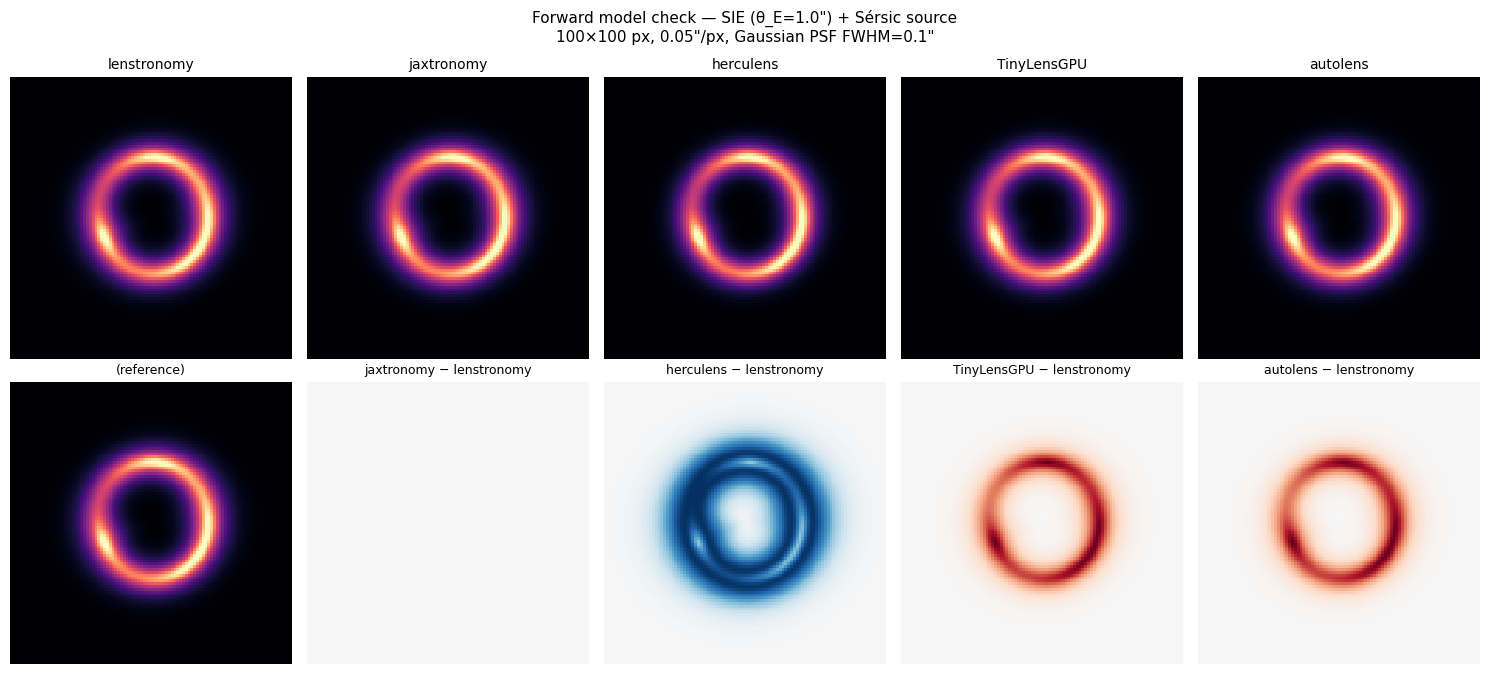

Saved forward_model_check.png


In [7]:
codes = ['lenstronomy', 'jaxtronomy', 'herculens', 'TinyLensGPU', 'autolens']
n = len([c for c in codes if c in images])

fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))

ref = images.get('lenstronomy')

for i, code in enumerate([c for c in codes if c in images]):
    img = images[code]
    vmax = np.percentile(img, 99.5)

    axes[0, i].imshow(img, origin='lower', cmap='magma', vmin=0, vmax=vmax)
    axes[0, i].set_title(code, fontsize=10)
    axes[0, i].axis('off')

    if ref is not None and code != 'lenstronomy':
        diff = img - ref
        lim  = max(np.max(np.abs(diff)), np.percentile(np.abs(ref), 99.5) * 1e-4)
        axes[1, i].imshow(diff, origin='lower', cmap='RdBu_r',
                          vmin=-lim, vmax=lim)
        axes[1, i].set_title(f'{code} − lenstronomy', fontsize=9)
    else:
        axes[1, i].imshow(img, origin='lower', cmap='magma', vmin=0, vmax=vmax)
        axes[1, i].set_title('(reference)', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Image', fontsize=10)
axes[1, 0].set_ylabel('Residual vs lenstronomy', fontsize=10)

plt.suptitle(
    f'Forward model check — SIE (θ_E={THETA_E}") + Sérsic source\n'
    f'{N_PIX}×{N_PIX} px, {PIX_SCALE}"/px, Gaussian PSF FWHM={PSF_FWHM}"',
    fontsize=11
)
plt.tight_layout()
plt.savefig('forward_model_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved forward_model_check.png')

In [8]:
# Numerical comparison against lenstronomy reference
if 'lenstronomy' in images:
    ref = images['lenstronomy']
    print(f'{'Code':<15} {'Max abs diff':>14} {'Max rel diff':>14}')
    print('-' * 45)
    for code in codes:
        if code == 'lenstronomy' or code not in images:
            continue
        diff     = images[code] - ref
        abs_diff = np.max(np.abs(diff))
        rel_diff = np.max(np.abs(diff) / (np.abs(ref) + 1e-10))
        print(f'{code:<15} {abs_diff:>14.6f} {rel_diff:>14.6f}')

Code              Max abs diff   Max rel diff
---------------------------------------------
jaxtronomy            0.000000       0.000000
herculens             0.005456       0.821476
TinyLensGPU          45.171387     401.288003
autolens             44.664343     435.500828
